In [3]:
#%pip install matplotlib
import pandas as pd
import requests
import matplotlib.pyplot as plt

In [4]:
# get data from API
url = "https://api.porssisahko.net/v2/latest-prices.json"
data = requests.get(url).json()['prices']

In [5]:
# convert to DataFrame
df = pd.DataFrame(data)

In [ ]:
# first few rows and last few rows
print(df.head())
print(df.tail())

    price                 startDate                   endDate
0  14.091  2026-01-27T22:45:00.000Z  2026-01-27T22:59:59.999Z
1  16.329  2026-01-27T22:30:00.000Z  2026-01-27T22:44:59.999Z
2  18.824  2026-01-27T22:15:00.000Z  2026-01-27T22:29:59.999Z
3  18.838  2026-01-27T22:00:00.000Z  2026-01-27T22:14:59.999Z
4  18.824  2026-01-27T21:45:00.000Z  2026-01-27T21:59:59.999Z
      price                 startDate                   endDate
187  12.475  2026-01-26T00:00:00.000Z  2026-01-26T00:14:59.999Z
188  12.324  2026-01-25T23:45:00.000Z  2026-01-25T23:59:59.999Z
189  12.378  2026-01-25T23:30:00.000Z  2026-01-25T23:44:59.999Z
190  12.775  2026-01-25T23:15:00.000Z  2026-01-25T23:29:59.999Z
191  12.865  2026-01-25T23:00:00.000Z  2026-01-25T23:14:59.999Z


In [7]:
# check data types and missing values
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   price      192 non-null    float64
 1   startDate  192 non-null    str    
 2   endDate    192 non-null    str    
dtypes: float64(1), str(2)
memory usage: 4.6 KB
None


In [8]:
# basic statistics
print(df.describe())

            price
count  192.000000
mean    23.703000
std      8.846792
min     11.671000
25%     15.025500
50%     22.125500
75%     30.670250
max     43.171000


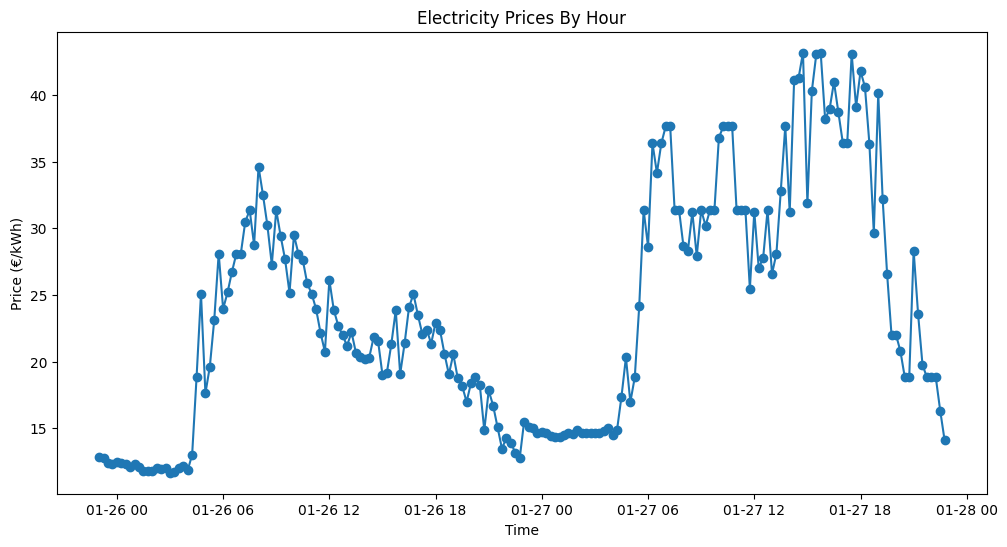

In [10]:
# change timestamp to to datetime
df['startDate'] = pd.to_datetime(df['startDate'])

# plot prices over time
df = df.sort_values('startDate')
plt.figure(figsize=(12, 6))
plt.plot(df['startDate'], df['price'], marker='o')
plt.title('Electricity Prices By Hour')
plt.xlabel('Time')
plt.ylabel('Price (€/kWh)')
plt.show()